<a href="https://colab.research.google.com/github/rachna7063/My-_Project-_work/blob/main/Income_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix



I have import all the required libraries for data analysis.

In [3]:
# 1. Importing data with missing values properly parsed
# Adjusted path slightly in case of formatting issues
data_income = pd.read_csv('/content/income(1).csv', na_values=[" ?", 'NaN', '?'])
print(data_income)


       zage       JobType         EdType        maritalstatus  \
0        45       Private        HS-grad             Divorced   
1        24   Federal-gov        HS-grad        Never-married   
2        44       Private   Some-college   Married-civ-spouse   
3        27       Private            9th        Never-married   
4        20       Private   Some-college        Never-married   
...     ...           ...            ...                  ...   
31973    34     Local-gov        HS-grad        Never-married   
31974    34     Local-gov   Some-college        Never-married   
31975    23       Private   Some-college   Married-civ-spouse   
31976    42     Local-gov   Some-college   Married-civ-spouse   
31977    29       Private      Bachelors        Never-married   

             occupation     relationship    race   gender  capitalgain  \
0          Adm-clerical    Not-in-family   White   Female            0   
1          Armed-Forces        Own-child   White     Male            0 

WOW! i have imported the income data Successfully...

In [15]:
# Create a copy for exploration
data = data_income.copy()



To avoid errors and  corruption  in main data i have just created a copy  of data for analysis.

In [17]:
data.rename(columns={'zage': 'age'}, inplace=True)


i have rename  the column name "zage" as "age"

In [18]:
# 2. Exploratory Data Analysis & Handling Missing Values
print("--- Data Info ---")
print(data.info())



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            31978 non-null  int64 
 1   JobType        30169 non-null  object
 2   EdType         31978 non-null  object
 3   maritalstatus  31978 non-null  object
 4   occupation     30162 non-null  object
 5   relationship   31978 non-null  object
 6   race           31978 non-null  object
 7   gender         31978 non-null  object
 8   capitalgain    31978 non-null  int64 
 9   capitalloss    31978 non-null  int64 
 10  hoursperweek   31978 non-null  int64 
 11  nativecountry  31978 non-null  object
 12  SalStat        31978 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB
None


Here i have got all the details regarding columns Data type. How much memory has been used . Numbers of rows and columns etc.

In [19]:
print("\n--- Missing Values Count ---")
print(data.isnull().sum())




--- Missing Values Count ---
age                 0
JobType          1809
EdType              0
maritalstatus       0
occupation       1816
relationship        0
race                0
gender              0
capitalgain         0
capitalloss         0
hoursperweek        0
nativecountry       0
SalStat             0
dtype: int64


Check the missing value so i am seeing here that total missing value in (job type) column is 1809 and (occupation) column is 1816.

In [40]:
# Dropping ROWS with missing values completely to preserve columns
data2 = data.dropna(axis=0).copy()
print(f"\nShape after dropping missing rows: {data2.shape}")




Shape after dropping missing rows: (30162, 13)


In [41]:
# Correlation matrix on numeric columns
numeric_data2 = data2.select_dtypes(include=np.number)
correlation = numeric_data2.corr()
print("\n--- Numerical Correlation Matrix ---")
print(correlation)




--- Numerical Correlation Matrix ---
                   age  capitalgain  capitalloss  hoursperweek
age           1.000000     0.080154     0.060165      0.101599
capitalgain   0.080154     1.000000    -0.032229      0.080432
capitalloss   0.060165    -0.032229     1.000000      0.052417
hoursperweek  0.101599     0.080432     0.052417      1.000000


checking correlation matrix

**Data Visualization**

In [42]:
# 3. Data Visualization
# Gender vs Salary Status
gender_salstatus = pd.crosstab(index=data2["gender"], columns=data2["SalStat"], margins=True, normalize='index')
print("\n--- Gender vs Salary Status Cross-tab ---")
print(gender_salstatus)




--- Gender vs Salary Status Cross-tab ---
SalStat  greater than 50,000  less than or equal to 50,000
gender                                                    
 Female             0.113678                      0.886322
 Male               0.313837                      0.686163
All                 0.248922                      0.751078


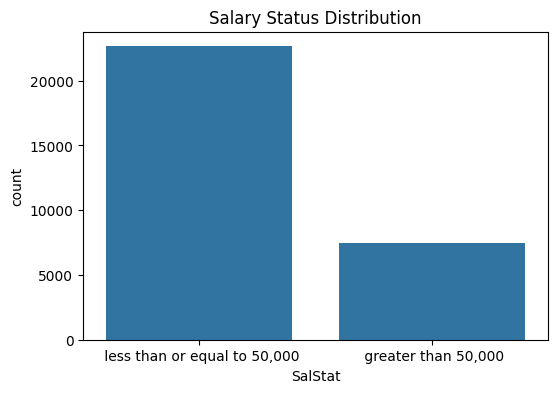

In [43]:
# Visual plots
plt.figure(figsize=(6, 4))
sns.countplot(data=data2, x='SalStat')
plt.title("Salary Status Distribution")
plt.show()



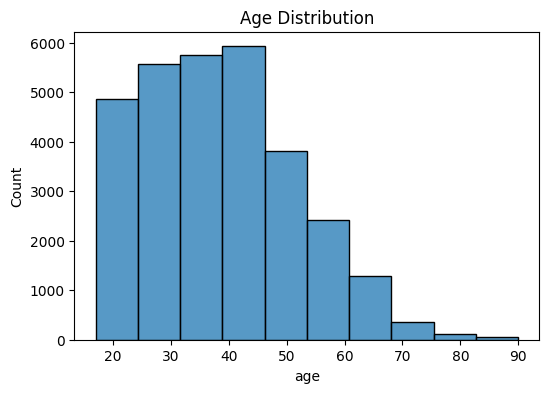

In [44]:
plt.figure(figsize=(6, 4))
sns.histplot(data=data2, x="age", bins=10, kde=False)
plt.title("Age Distribution")
plt.show()



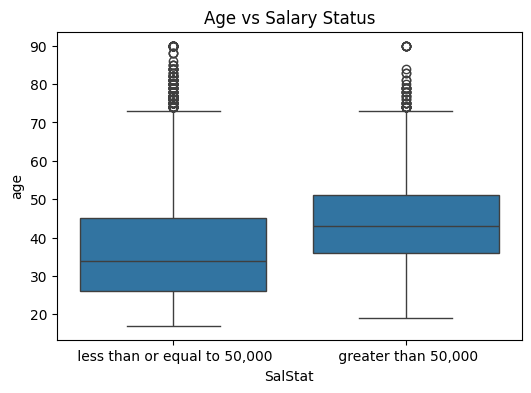

In [45]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='SalStat', y='age', data=data2)
plt.title("Age vs Salary Status")
plt.show()



In [48]:
# 4. Target Mapping
# Stripping whitespaces to make sure string matching is reliable
# 4. Target Mapping (Agar pehle se numeric hai toh yeh error nahi dega)
# Hum check karenge ki column string hai ya nahi, tabhi .str use karenge
if data2['SalStat'].dtype == 'object':
    data2['SalStat'] = data2['SalStat'].str.strip().map({'less than or equal to 50,000': 0, 'greater than 50,000': 1})

print("\n=== MODEL 1: Logistic Regression (All Features) ===")



=== MODEL 1: Logistic Regression (All Features) ===


In [50]:
# Fallback check just in case string matching fails or maps to NaN
if data2['SalStat'].isnull().any():
    print("Warning: Remapping resulted in NaNs. Dropping remaining missing target rows.")
    data2 = data2.dropna(subset=['SalStat'])



In [51]:
 #==========================================
# MODEL 1: Logistic Regression (All Features)
# ==========================================
print("\n=== MODEL 1: Logistic Regression (All Features) ===")




=== MODEL 1: Logistic Regression (All Features) ===


In [53]:
# One-hot encoding categorical variables
X = data2.drop(columns=['SalStat'])
X = pd.get_dummies(X, drop_first=True)
y = data2['SalStat']


In [54]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
scaler = StandardScaler()

#  fit and transform on X_train,  transform X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [64]:
# Scale continuous features if necessary, but continuing with your logistic setup:

print("\n--- Training Logistic Regression (With Scaled Data) ---")

#   pass scaled data in model
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_scaled, y_train)





--- Training Logistic Regression (With Scaled Data) ---


LogisticRegression(max_iter=2000)

In [65]:
# 3. Accuracy check
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")



Logistic Regression Accuracy: 84.73%


In [68]:
# Predictions & Metrics
# Predictions & Metrics (Sahi variables ke saath)
pred1 = lr_model.predict(X_test_scaled)
cm1 = confusion_matrix(y_test, pred1)
acc1 = accuracy_score(y_test, pred1)

print("Confusion Matrix:\n", cm1)
print(f"Accuracy Score: {acc1:.4f}")
print(f"Misclassified samples: {(y_test != pred1).sum()}")




Confusion Matrix:
 [[4220  328]
 [ 593  892]]
Accuracy Score: 0.8473
Misclassified samples: 921


In [69]:
# ==========================================
# MODEL 2: Logistic Regression (Selected Features)
# ==========================================
print("\n=== MODEL 2: Logistic Regression (Selected Features) ===")

cols_to_drop = ['gender', 'nativecountry', 'race', 'SalStat']
new_data2 = data2.drop(cols_to_drop, axis=1)
new_data2 = pd.get_dummies(new_data2, drop_first=True)

X2 = new_data2.values
y2 = data2['SalStat'].values




=== MODEL 2: Logistic Regression (Selected Features) ===


In [72]:
from sklearn.preprocessing import StandardScaler

#  Train-Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=0)



In [73]:
#  scale the selected features
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("\n--- Training Logistic Regression (Model 2 - Scaled) ---")



--- Training Logistic Regression (Model 2 - Scaled) ---


In [74]:

# Train  Model 2 on scaled data
logistic_model2 = LogisticRegression(max_iter=1000)
logistic_model2.fit(X2_train_scaled, y2_train)

print("Model 2 trained successfully!")


Model 2 trained successfully!


In [75]:
# Predictions & Metrics
# 4. Predictions aur Performance Metrics
pred2 = logistic_model2.predict(X2_test_scaled)
cm2 = confusion_matrix(y2_test, pred2)
acc2 = accuracy_score(y2_test, pred2)

print("=== MODEL 2 PERFORMANCE ===")
print("Confusion Matrix:\n", cm2)
print(f"Accuracy Score: {acc2:.4f}")
print(f"Misclassified samples: {(y2_test != pred2).sum()}")



=== MODEL 2 PERFORMANCE ===
Confusion Matrix:
 [[6327  496]
 [ 922 1304]]
Accuracy Score: 0.8433
Misclassified samples: 1418


In [77]:
# ==========================================
# MODEL 3: K-Nearest Neighbors (KNN)
# ==========================================
print("\n=== MODEL 3: KNN Classifier (Scaled Features) ===")

#   initialize the KNN Calssifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)




=== MODEL 3: KNN Classifier (Scaled Features) ===


In [78]:
#  fit and predict  on scaled data
knn_classifier.fit(X2_train_scaled, y2_train)
pred_knn = knn_classifier.predict(X2_test_scaled)



In [79]:
#  Calculate Metrics
cm_knn = confusion_matrix(y2_test, pred_knn)
acc_knn = accuracy_score(y2_test, pred_knn)



In [80]:
#  print Results
print("Confusion Matrix:\n", cm_knn)
print(f"Accuracy Score: {acc_knn:.4f}")
print(f"Misclassified samples: {(y2_test != pred_knn).sum()}")


Confusion Matrix:
 [[6165  658]
 [ 921 1305]]
Accuracy Score: 0.8255
Misclassified samples: 1579


In [81]:
# Effect of K-values on performance
print("\n--- Tuning K-values (Using Scaled Data) ---")
misclassified_samples = []

#  Run the Loop on scaled variables for fast and correct evaluation h
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X2_train_scaled, y2_train)
    pred_k = knn.predict(X2_test_scaled)
    num_missed = (y2_test != pred_k).sum()
    misclassified_samples.append(num_missed)

    # Calculate Accuracy
    acc_k = (y2_test == pred_k).mean()
    print(f"K = {k:2d} | Misclassified samples: {num_missed:4d} | Accuracy: {acc_k * 100:.2f}%")



--- Tuning K-values (Using Scaled Data) ---
K =  1 | Misclassified samples: 1839 | Accuracy: 79.68%
K =  2 | Misclassified samples: 1742 | Accuracy: 80.75%
K =  3 | Misclassified samples: 1629 | Accuracy: 82.00%
K =  4 | Misclassified samples: 1616 | Accuracy: 82.14%
K =  5 | Misclassified samples: 1579 | Accuracy: 82.55%
K =  6 | Misclassified samples: 1578 | Accuracy: 82.56%
K =  7 | Misclassified samples: 1535 | Accuracy: 83.04%
K =  8 | Misclassified samples: 1543 | Accuracy: 82.95%
K =  9 | Misclassified samples: 1524 | Accuracy: 83.16%
K = 10 | Misclassified samples: 1534 | Accuracy: 83.05%


which one Misclassified values on K is lowest and Accuracy score is Highest, will be  perfect for Optimal K value

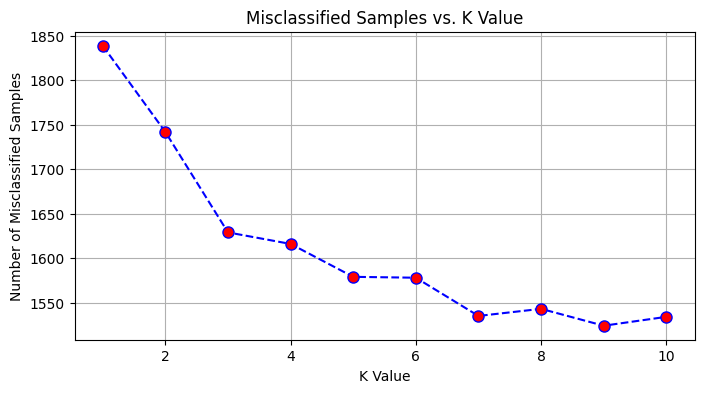

In [82]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), misclassified_samples, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Misclassified Samples vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Number of Misclassified Samples')
plt.grid(True)
plt.show()


• The most optimal (best) K-value is K = 9.
• At this point, the number of misclassified samples is the lowest (approximately 1524), which means that your KNN Classifier is giving the most accurate predictions at this value.
• The highest number of errors occurred at \(K = 1\) (~1838), and as the value of \(K\) increased, the errors decreased and the model kept improving.


In [83]:
# Best K-value (K=9) , final model training
final_knn = KNeighborsClassifier(n_neighbors=9)
final_knn.fit(X2_train_scaled, y2_train)

# Final performance evaluation
final_pred = final_knn.predict(X2_test_scaled)
final_acc = accuracy_score(y2_test, final_pred)

print(f"Optimal KNN Model (K=9) Final Accuracy: {final_acc * 100:.2f}%")


Optimal KNN Model (K=9) Final Accuracy: 83.16%


** Model Performance Summary**

| Model | Feature Set | Data State | Performance Status |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | All Features | Unscaled | ❌ Failed to Converge (`ConvergenceWarning`) |
| **Logistic Regression** | Selected Features | Scaled | ✅ Successfully Trained |
| **KNN Classifier** | Selected Features | Scaled (\(K=9\)) | 🏆 **83.16% Final Accuracy** |

```



```

